In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

folder_path = "/content/drive/My Drive/DS 340W"

print(os.listdir(folder_path))

['project_papers', 'dataset.csv', 'DS 340W Notes.gdoc', 'test.csv', 'train.csv', 'validation.csv', 'cnn_lstm_seed_results.csv']


In [5]:
import pandas as pd

train_df = pd.read_csv(f"{folder_path}/train.csv")
val_df = pd.read_csv(f"{folder_path}/validation.csv")
test_df = pd.read_csv(f"{folder_path}/test.csv")

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Testing:", test_df.shape)

Training: (4494, 3)
Validation: (642, 3)
Testing: (1284, 3)


In [7]:
# Check column names
print("Columns:", train_df.columns.tolist())

# Preview the training data
display(train_df.head())

# Check missing values
print("\nMissing values:")
print(train_df.isnull().sum())

# Check label distribution
print("\nTraining label distribution:")
print(train_df["label"].value_counts())

print("\nValidation label distribution:")
print(val_df["label"].value_counts())

print("\nTesting label distribution:")
print(test_df["label"].value_counts())

Columns: ['id', 'tweet', 'label']


,id,tweet,label
0,477,The novel coronavirus can be cured by one bowl...,fake
1,2434,At the peak in New York on April 15 that state...,real
2,4689,Video shows a huge crowd gathered in an Americ...,fake
3,5106,(2/4) Containment zones that refer to a specif...,real
4,2635,Australian Scientists referred to coronavirus ...,fake



Missing values:
id       0
tweet    0
label    0
dtype: int64

Training label distribution:
label
real    2352
fake    2142
Name: count, dtype: int64

Validation label distribution:
label
real    336
fake    306
Name: count, dtype: int64

Testing label distribution:
label
real    672
fake    612
Name: count, dtype: int64


In [8]:
# Convert labels to numeric values
# Fake = 0, Real = 1

label_map = {"fake": 0, "real": 1}

y_train = train_df["label"].map(label_map)
y_val = val_df["label"].map(label_map)
y_test = test_df["label"].map(label_map)

# Extract tweet text
X_train_text = train_df["tweet"].astype(str)
X_val_text = val_df["tweet"].astype(str)
X_test_text = test_df["tweet"].astype(str)

print("Training:", len(X_train_text), len(y_train))
print("Validation:", len(X_val_text), len(y_val))
print("Testing:", len(X_test_text), len(y_test))

print("\nEncoded training labels:")
print(y_train.value_counts())

Training: 4494 4494
Validation: 642 642
Testing: 1284 1284

Encoded training labels:
label
1    2352
0    2142
Name: count, dtype: int64


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Fit ONLY on training data
X_train = tfidf.fit_transform(X_train_text)

# Transform validation and test data
X_val = tfidf.transform(X_val_text)
X_test = tfidf.transform(X_test_text)

print("Training TF-IDF shape:", X_train.shape)
print("Validation TF-IDF shape:", X_val.shape)
print("Testing TF-IDF shape:", X_test.shape)

Training TF-IDF shape: (4494, 10000)
Validation TF-IDF shape: (642, 10000)
Testing TF-IDF shape: (1284, 10000)


In [10]:
!pip -q install xgboost

import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [11]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost training complete!")

XGBoost training complete!


In [12]:
# Predict validation labels
y_val_pred = xgb_model.predict(X_val)

# Calculate evaluation metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

print("XGBoost Validation Results")
print("--------------------------")
print(f"Accuracy:  {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall:    {val_recall:.4f}")
print(f"F1 Score:  {val_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_val_pred,
    target_names=["Fake", "Real"]
))

XGBoost Validation Results
--------------------------
Accuracy:  0.9034
Precision: 0.9152
Recall:    0.8988
F1 Score:  0.9069

Classification Report:
              precision    recall  f1-score   support

        Fake       0.89      0.91      0.90       306
        Real       0.92      0.90      0.91       336

    accuracy                           0.90       642
   macro avg       0.90      0.90      0.90       642
weighted avg       0.90      0.90      0.90       642



In [13]:
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
import pandas as pd

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

results = []
best_f1 = -1
best_model = None
best_params = None

for params in ParameterGrid(param_grid):
    model = XGBClassifier(
        **params,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    predictions = model.predict(X_val)

    score = f1_score(
        y_val,
        predictions,
        average="macro"
    )

    results.append({
        **params,
        "macro_f1": score
    })

    if score > best_f1:
        best_f1 = score
        best_model = model
        best_params = params

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    "macro_f1",
    ascending=False
)

print("Top 5 parameter combinations:")
display(results_df.head())

print("\nBest parameters:")
print(best_params)

print(f"\nBest Validation Macro F1: {best_f1:.4f}")

Top 5 parameter combinations:


,colsample_bytree,learning_rate,max_depth,n_estimators,subsample,macro_f1
8,0.8,0.05,6,500,0.8,0.931334
17,0.8,0.10,6,500,0.8,0.929763
16,0.8,0.10,6,300,0.8,0.928147
13,0.8,0.10,4,300,0.8,0.926680
12,0.8,0.10,4,200,0.8,0.926680



Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 500, 'subsample': 0.8}

Best Validation Macro F1: 0.9313


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Predict test labels
y_test_pred = best_model.predict(X_test)

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(
    y_test, y_test_pred, average="macro"
)
test_recall = recall_score(
    y_test, y_test_pred, average="macro"
)
test_f1 = f1_score(
    y_test, y_test_pred, average="macro"
)

print("XGBoost Final Test Results")
print("--------------------------")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"Macro F1:  {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Fake", "Real"]
))

XGBoost Final Test Results
--------------------------
Accuracy:  0.9338
Precision: 0.9335
Recall:    0.9341
Macro F1:  0.9337

Classification Report:
              precision    recall  f1-score   support

        Fake       0.92      0.94      0.93       612
        Real       0.94      0.93      0.94       672

    accuracy                           0.93      1284
   macro avg       0.93      0.93      0.93      1284
weighted avg       0.93      0.93      0.93      1284



In [16]:
import os
import joblib
import json

save_path = "/content/drive/My Drive/DS 340W/XGBoost"
os.makedirs(save_path, exist_ok=True)

# Save the trained model
best_model.save_model(
    f"{save_path}/xgboost_model.json"
)

# Save TF-IDF vectorizer
joblib.dump(
    tfidf,
    f"{save_path}/tfidf_vectorizer.pkl"
)

# Save best hyperparameters
with open(f"{save_path}/best_params.json", "w") as f:
    json.dump(best_params, f, indent=4)

# Save test metrics
metrics = {
    "accuracy": test_accuracy,
    "macro_precision": test_precision,
    "macro_recall": test_recall,
    "macro_f1": test_f1
}

with open(f"{save_path}/test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("XGBoost model and results saved successfully!")

XGBoost model and results saved successfully!


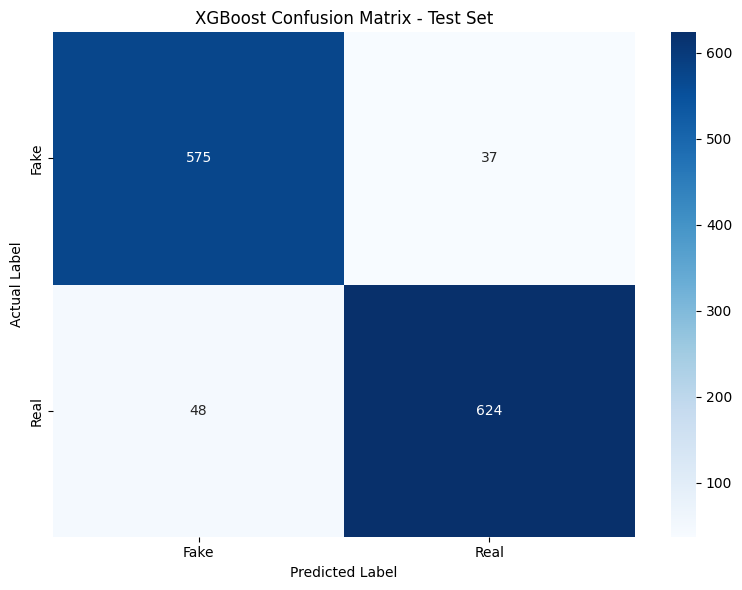

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix using test predictions
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.title("XGBoost Confusion Matrix - Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()